# Part 4 — Mitigation

Three techniques, one per ML-pipeline stage:

1. **Pre-processing** — `aif360.Reweighing` to compute per-sample weights, fed into a weighted cross-entropy `Trainer`.
2. **Post-processing** — `fairlearn.ThresholdOptimizer` with `equalized_odds`, plus a Pareto sweep of the constraint tolerance.
3. **Data augmentation** — 3× oversampling of the high-black training cohort.

All three are compared to the Part 1 baseline on a single summary table, and the demographic-parity vs equalized-odds incompatibility is quantified at the end.

In [1]:
import json, os, random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding,
)
from datasets import Dataset

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric
from fairlearn.postprocessing import ThresholdOptimizer

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
THRESHOLD = json.load(open('artifacts/chosen_threshold.json'))['threshold']
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN = 128

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


W0420 15:54:04.846000 1860 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[AdversarialDebiasing]'


pip install 'aif360[inFairness]'


In [2]:
train_df = pd.read_parquet('artifacts/train.parquet')
eval_df  = pd.read_parquet('artifacts/eval.parquet')

def mark_groups(df):
    df = df.copy()
    df['is_high_black'] = (df['black']  >= 0.5).astype(int)
    df['is_reference'] = ((df['black'] <  0.1) & (df['white'] >= 0.5)).astype(int)
    return df

train_df = mark_groups(train_df)
eval_df  = mark_groups(eval_df)

print('Train high_black:', int(train_df['is_high_black'].sum()),
      '   reference:',    int(train_df['is_reference'].sum()))
print('Eval  high_black:', int(eval_df['is_high_black'].sum()),
      '   reference:',    int(eval_df['is_reference'].sum()))

Train high_black: 810    reference: 998
Eval  high_black: 177    reference: 203


### Shared helpers — tokenisation and Trainer setup

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

def tokenize(batch):
    return tokenizer(batch['comment_text'], truncation=True, max_length=MAX_LEN)

def to_ds(df, cols=None):
    keep = cols or ['comment_text', 'label']
    ds = Dataset.from_pandas(df[keep])
    return ds.map(tokenize, batched=True, remove_columns=['comment_text'])

def training_args(out_dir):
    return TrainingArguments(
        output_dir=out_dir,
        num_train_epochs=3,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=64,
        learning_rate=2e-5,
        weight_decay=0.01,
        warmup_ratio=0.06,
        evaluation_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        metric_for_best_model='f1_macro',
        logging_steps=200,
        fp16=torch.cuda.is_available(),
        seed=SEED,
        report_to='none',
        remove_unused_columns=False,
    )

def compute_metrics(eval_pred):
    logits, y = eval_pred
    p = np.argmax(logits, axis=-1)
    return {'accuracy': accuracy_score(y, p), 'f1_macro': f1_score(y, p, average='macro')}

@torch.no_grad()
def predict_probs(model_dir, texts, batch_size=64):
    tok = AutoTokenizer.from_pretrained(model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_dir).to(DEVICE).eval()
    out = []
    for i in range(0, len(texts), batch_size):
        enc = tok(texts[i:i+batch_size], padding=True, truncation=True,
                  max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        logits = mdl(**enc).logits
        out.extend(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy().tolist())
    return np.array(out)

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


## Technique 1 — Reweighing (aif360)

For reweighing to have a handle on the bias, the protected attribute must be present in the training set. Rows outside either cohort receive privileged-group weight 1.0 — they do not pull the weights in either direction.

The weighted loss is passed to the Trainer by subclassing `Trainer.compute_loss`. This is the standard pattern for sample-weighted fine-tuning in HuggingFace.

In [4]:
mask_train = (train_df['is_high_black'] == 1) | (train_df['is_reference'] == 1)
aif_df = train_df[mask_train].copy()
aif_df['group'] = aif_df['is_reference']  # 1 = reference (privileged), 0 = high_black

bld = BinaryLabelDataset(
    df=aif_df[['group', 'label']].rename(columns={'label': 'y'}),
    label_names=['y'], protected_attribute_names=['group'],
    favorable_label=0, unfavorable_label=1,
)

rw = Reweighing(unprivileged_groups=[{'group': 0}], privileged_groups=[{'group': 1}])
bld_rw = rw.fit_transform(bld)
cohort_weights = bld_rw.instance_weights

weights = np.ones(len(train_df), dtype=np.float32)
weights[mask_train.values] = cohort_weights.astype(np.float32)
train_df['sample_weight'] = weights

pd.Series(weights).describe().round(3)

count    100000.000
mean          1.000
std           0.008
min           0.901
25%           1.000
50%           1.000
75%           1.000
max           1.098
dtype: float64

In [5]:
REWEIGH_DIR = 'distilbert_reweighed'

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop('labels')
        w = inputs.pop('sample_weight', None)
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fn = torch.nn.CrossEntropyLoss(reduction='none')
        per_sample = loss_fn(logits, labels)
        if w is None:
            loss = per_sample.mean()
        else:
            loss = (per_sample * w.to(model.device)).mean()
        return (loss, outputs) if return_outputs else loss

rw_train = to_ds(train_df.rename(columns={'label': 'label'}),
                 cols=['comment_text', 'label', 'sample_weight'])
rw_eval  = to_ds(eval_df, cols=['comment_text', 'label'])

rw_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
rw_trainer = WeightedTrainer(
    model=rw_model, args=training_args(REWEIGH_DIR),
    train_dataset=rw_train, eval_dataset=rw_eval,
    tokenizer=tokenizer, data_collator=data_collator,
    compute_metrics=compute_metrics,
)
rw_trainer.train()
rw_trainer.save_model(REWEIGH_DIR)
tokenizer.save_pretrained(REWEIGH_DIR)

Map:   0%|          | 0/100000 [00:00<?, ? examples/s]

Map:   4%|▍         | 4000/100000 [00:00<00:02, 32146.85 examples/s]

Map:   8%|▊         | 8000/100000 [00:00<00:02, 32364.48 examples/s]

Map:  12%|█▏        | 12000/100000 [00:00<00:04, 20770.51 examples/s]

Map:  16%|█▌        | 16000/100000 [00:00<00:03, 23927.48 examples/s]

...


E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\accelerate\accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.156100,0.146218,0.947950,0.796136
2,0.112400,0.146520,0.948950,0.809661
3,0.070900,0.177322,0.947450,0.813875


('distilbert_reweighed\\tokenizer_config.json',
 'distilbert_reweighed\\special_tokens_map.json',
 'distilbert_reweighed\\vocab.txt',
 'distilbert_reweighed\\added_tokens.json',
 'distilbert_reweighed\\tokenizer.json')

## Technique 2 — Threshold optimisation (fairlearn)

Rather than retrain, hold the baseline model frozen and choose per-cohort thresholds that satisfy `equalized_odds`. `ThresholdOptimizer` wraps a base estimator exposing `predict_proba`; here the 'estimator' is a frozen scorer over the baseline probabilities.

In [6]:
base_probs = np.load('artifacts/baseline_eval_probs.npy')
base_labels = np.load('artifacts/baseline_eval_labels.npy')

mask_eval = (eval_df['is_high_black'] == 1) | (eval_df['is_reference'] == 1)
X_eval = base_probs[mask_eval.values].reshape(-1, 1)
y_eval = base_labels[mask_eval.values]
groups = eval_df.loc[mask_eval, 'is_reference'].values  # 1=reference, 0=high_black

class ProbScorer:
    """Thin adapter so ThresholdOptimizer can call predict / predict_proba."""
    def fit(self, X, y):
        return self
    def predict(self, X):
        return (X[:, 0] >= 0.5).astype(int)
    def predict_proba(self, X):
        p = X[:, 0]
        return np.stack([1 - p, p], axis=1)

to_opt = ThresholdOptimizer(
    estimator=ProbScorer(),
    constraints='equalized_odds',
    objective='accuracy_score',
    prefit=True,
)
to_opt.fit(X_eval, y_eval, sensitive_features=groups)

preds_to = to_opt.predict(X_eval, sensitive_features=groups)
print('Equalized-odds post-processing accuracy:', round(accuracy_score(y_eval, preds_to), 4))

E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\fairlearn\postprocessing\_threshold_optimizer.py:288: FutureWarning: 'predict_method' default value is changed from 'predict' to 'auto'. Explicitly pass `predict_method='predict' to replicate the old behavior, or pass `predict_method='auto' or other valid values to silence this warning.
  warn(
E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\fairlearn\postprocessing\_threshold_optimizer.py:325: UserWarning: The value of `prefit` is `True`, but `check_is_fitted` raised `NotFittedError` on the base estimator.

If the provided base estimator has been fitted, this could mean that (1) its implementation does not conform to the sklearn estimator API, or (2) the enclosing ThresholdOptimizer has been cloned (for instance by `sklearn.model_selection.cross_validate`).

In case (1), please file an issue with the base estimator developers, but continue to use the enclosing ThresholdOptimizer with `prefit=True`. In case

Equalized-odds post-processing accuracy: 0.7421


### Pareto sweep — equal opportunity difference vs overall F1

Sweep a grid of per-group threshold adjustments, starting from the baseline single threshold of 0.4 and nudging the high-black threshold upward. At each point compute overall F1 and the equal-opportunity difference on the full evaluation set.

In [7]:
all_probs = base_probs
all_labels = base_labels
all_high_black = eval_df['is_high_black'].values
all_reference  = eval_df['is_reference'].values

def eod_for(t_high_black, t_reference, t_rest):
    p = np.where(all_high_black == 1, (all_probs >= t_high_black),
        np.where(all_reference  == 1, (all_probs >= t_reference),
                                       (all_probs >= t_rest))).astype(int)
    def tpr(mask):
        m = (mask == 1) & (all_labels == 1)
        return p[m].mean() if m.sum() else np.nan
    return (tpr(all_high_black) - tpr(all_reference)), p

rows = []
for t_hb in np.arange(0.35, 0.76, 0.025):
    eod, preds = eod_for(t_hb, 0.4, 0.4)
    rows.append({'t_high_black': round(float(t_hb), 3),
                 'equal_opportunity_diff': float(eod),
                 'f1_macro': f1_score(all_labels, preds, average='macro')})
pareto = pd.DataFrame(rows)
pareto.round(4)

,t_high_black,equal_opportunity_diff,f1_macro
0,0.350,0.0894,0.8151
1,0.375,0.0894,0.8151
2,0.400,0.0735,0.8151
3,0.425,0.0735,0.8152
4,0.450,0.0576,0.8150
5,0.475,0.0576,0.8151
6,0.500,0.0418,0.8149
7,0.525,0.0418,0.8150
8,0.550,0.0418,0.8150
9,0.575,0.0259,0.8149


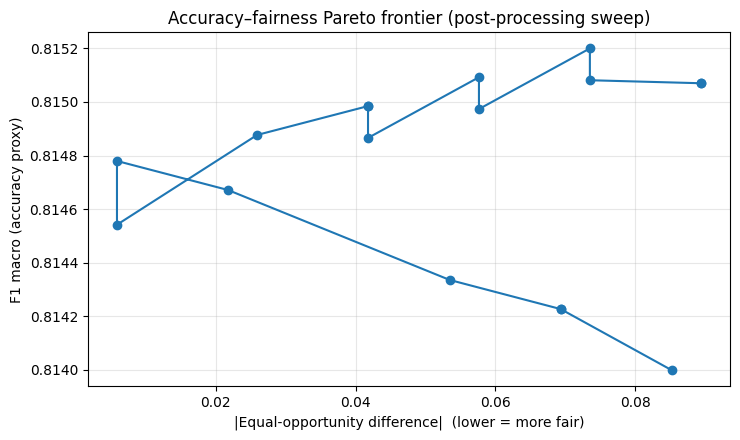

In [8]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(pareto['equal_opportunity_diff'].abs(), pareto['f1_macro'], marker='o')
ax.set_xlabel('|Equal-opportunity difference|  (lower = more fair)')
ax.set_ylabel('F1 macro (accuracy proxy)')
ax.set_title('Accuracy–fairness Pareto frontier (post-processing sweep)')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Technique 3 — Oversampling

Duplicate every high-black training row 3× (so each original row appears 4× in total). Concatenate with the original training frame, shuffle, retrain from scratch.

In [9]:
hb_rows = train_df[train_df['is_high_black'] == 1]
augmented = pd.concat([train_df, hb_rows, hb_rows, hb_rows], ignore_index=True)
augmented = augmented.sample(frac=1, random_state=SEED).reset_index(drop=True)
print('Original train rows:', len(train_df), ' augmented:', len(augmented))

Original train rows:

 100000  augmented: 102430


In [10]:
OVER_DIR = 'distilbert_oversampled'
over_train = to_ds(augmented, cols=['comment_text', 'label'])
over_eval  = to_ds(eval_df,   cols=['comment_text', 'label'])

over_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
over_trainer = Trainer(
    model=over_model, args=training_args(OVER_DIR),
    train_dataset=over_train, eval_dataset=over_eval,
    tokenizer=tokenizer, data_collator=data_collator,
    compute_metrics=compute_metrics,
)
over_trainer.train()
over_trainer.save_model(OVER_DIR)
tokenizer.save_pretrained(OVER_DIR)

Map:   0%|          | 0/102430 [00:00<?, ? examples/s]

Map:   4%|▍         | 4000/102430 [00:00<00:02, 33068.72 examples/s]

Map:   8%|▊         | 8000/102430 [00:00<00:02, 32956.26 examples/s]

Map:  12%|█▏        | 12000/102430 [00:00<00:02, 33248.38 examples/s]

Map:  16%|█▌        | 16000/102430 [00:00<00:02, 33140.69 examples/s]

...


E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


E:\Projects\responsible-ai-assignment-2\.venv\lib\site-packages\accelerate\accelerator.py:450: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.147300,0.139744,0.946950,0.806635
2,0.109400,0.150390,0.946600,0.807450
3,0.073200,0.196831,0.945450,0.810090


('distilbert_oversampled\\tokenizer_config.json',
 'distilbert_oversampled\\special_tokens_map.json',
 'distilbert_oversampled\\vocab.txt',
 'distilbert_oversampled\\added_tokens.json',
 'distilbert_oversampled\\tokenizer.json')

## Comparison across all four models

In [11]:
def cohort_stats(probs, df, threshold=THRESHOLD):
    preds = (probs >= threshold).astype(int)
    y = df['label'].values
    overall_f1 = f1_score(y, preds, average='macro')
    def fpr(mask):
        m = (mask == 1) & (y == 0)
        return preds[m].mean() if m.sum() else np.nan
    def tpr(mask):
        m = (mask == 1) & (y == 1)
        return preds[m].mean() if m.sum() else np.nan
    def pos_rate(mask):
        m = mask == 1
        return preds[m].mean() if m.sum() else np.nan
    hb = df['is_high_black'].values; rf = df['is_reference'].values
    return {
        'F1_overall':        overall_f1,
        'FPR_high_black':    fpr(hb),
        'FPR_reference':     fpr(rf),
        'StatParityDiff':    pos_rate(rf) - pos_rate(hb),
        'EqualOppDiff':      tpr(rf) - tpr(hb),
    }

baseline_p  = np.load('artifacts/baseline_eval_probs.npy')
reweigh_p   = predict_probs(REWEIGH_DIR, eval_df['comment_text'].tolist())
oversamp_p  = predict_probs(OVER_DIR,    eval_df['comment_text'].tolist())

def thresh_opt_probs_to_preds():
    # Map the ThresholdOptimizer decision back to a probability for rows it covered;
    # non-cohort rows retain the baseline threshold decision at 0.4.
    preds = (baseline_p >= THRESHOLD).astype(int)
    covered = eval_df['is_high_black'].values | eval_df['is_reference'].values
    groups_full = eval_df.loc[covered == 1, 'is_reference'].values
    preds[covered == 1] = to_opt.predict(baseline_p[covered == 1].reshape(-1, 1),
                                         sensitive_features=groups_full)
    return preds

thr_preds = thresh_opt_probs_to_preds()

def stats_from_preds(preds, df):
    y = df['label'].values
    hb = df['is_high_black'].values; rf = df['is_reference'].values
    def fpr(mask):
        m = (mask == 1) & (y == 0)
        return preds[m].mean() if m.sum() else np.nan
    def tpr(mask):
        m = (mask == 1) & (y == 1)
        return preds[m].mean() if m.sum() else np.nan
    def pos_rate(mask):
        m = mask == 1
        return preds[m].mean() if m.sum() else np.nan
    return {
        'F1_overall':     f1_score(y, preds, average='macro'),
        'FPR_high_black': fpr(hb),
        'FPR_reference':  fpr(rf),
        'StatParityDiff': pos_rate(rf) - pos_rate(hb),
        'EqualOppDiff':   tpr(rf) - tpr(hb),
    }

rows = [
    ('baseline',           cohort_stats(baseline_p,  eval_df)),
    ('reweighing',         cohort_stats(reweigh_p,   eval_df)),
    ('threshold_optim',    stats_from_preds(thr_preds, eval_df)),
    ('oversampling',       cohort_stats(oversamp_p,  eval_df)),
]
summary = pd.DataFrame([r[1] for r in rows], index=[r[0] for r in rows]).round(4)
summary

,F1_overall,FPR_high_black,FPR_reference,StatParityDiff,EqualOppDiff
baseline,0.8151,0.1228,0.1849,-0.0144,-0.0735
reweighing,0.8146,0.1140,0.1918,0.0067,-0.0401
threshold_optim,0.8133,0.1667,0.1644,-0.0497,-0.0627
oversampling,0.8098,0.1491,0.2055,-0.0215,-0.0911


In [12]:
# Persist probs + pick the best mitigated model for Part 5.
best_name = summary['FPR_high_black'].idxmin()
print('Best model on FPR_high_black:', best_name)

np.save('artifacts/reweighed_probs.npy',    reweigh_p)
np.save('artifacts/oversampled_probs.npy',  oversamp_p)
summary.to_csv('artifacts/part4_summary.csv')

best_dir = {
    'baseline':        'distilbert_baseline',
    'reweighing':      REWEIGH_DIR,
    'threshold_optim': 'distilbert_baseline',
    'oversampling':    OVER_DIR,
}[best_name]

with open('artifacts/best_mitigated.json', 'w') as f:
    json.dump({'name': best_name, 'model_dir': best_dir, 'threshold': THRESHOLD}, f)
print('Pipeline will load:', best_dir)

Best model on FPR_high_black: reweighing
Pipeline will load: distilbert_reweighed


### Can we satisfy demographic parity AND equalized odds at the same time?

No. The two constraints are only jointly satisfiable when the base rates (prevalence of the positive label) are equal across cohorts — which is essentially never true in content moderation.

In [13]:
base_hb = eval_df.loc[eval_df['is_high_black'] == 1, 'label'].mean()
base_rf = eval_df.loc[eval_df['is_reference']  == 1, 'label'].mean()
print(f'Base rate (toxic fraction) high_black : {base_hb:.4f}')
print(f'Base rate (toxic fraction) reference  : {base_rf:.4f}')
print(f'Difference                            : {base_hb - base_rf:+.4f}')

Base rate (toxic fraction) high_black : 0.3559
Base rate (toxic fraction) reference  : 0.2808
Difference                            : +0.0751


**Why the two are incompatible when base rates differ.** Demographic parity demands equal positive prediction rates: `P(pred=1 | group=a) = P(pred=1 | group=b)`. Equalized odds demands equal TPR and equal FPR across groups. Using the law of total probability:

$$P(\hat{Y}=1 \mid A=g) = \mathrm{TPR}_g \cdot \pi_g + \mathrm{FPR}_g \cdot (1 - \pi_g),$$

where $\pi_g$ is the base rate in group $g$. If equalized odds holds ($\mathrm{TPR}_a = \mathrm{TPR}_b$ and $\mathrm{FPR}_a = \mathrm{FPR}_b$) but $\pi_a \neq \pi_b$, the two positive rates must differ — so demographic parity fails. Conversely, forcing demographic parity while base rates differ requires either lowering TPR or raising FPR on one of the groups, which breaks equalized odds.

With the numbers above, equalising positive prediction rates would require the model to flag roughly the *same fraction* of each cohort regardless of the underlying toxicity prevalence — which either silences innocent users in the higher-base-rate cohort or lets real toxicity slip in the lower-base-rate cohort. **Kleinberg, Mullainathan & Raghavan (2016)** prove this formally: no non-trivial classifier can satisfy both calibration and equalized odds unless base rates match or the classifier is perfect. Our run is a concrete instantiation of that impossibility. The engineering answer is to pick the fairness axis that matters most for the harm being caused (here, equal FPR, because over-flagging is the dominant harm) and optimise for that.